SPECTRAL DESCRIPTORS AND FUNCTIONAL MAPS

In [1]:
import pyFM
import dense_mesh as dm
from pyFM import mesh
from pyFM import functional
from pyFM import eval

from shape_utils.spectral_descr import  calculate_spectral_descriptors
from shape_utils.utils import find_minimum_distance_meshes, save_data_to_csv, save_list_to_csv
from shape_utils.functional_maps import calculate_functional_maps, set_FM_model_parameters, calculate_p2p_map, calculate_scalable_functional_maps
from shape_utils.similarity_scores import calculate_geodesic_norm_score
from analysis_tools.visualisation_correspondence import visualize_correspondence_meshplot, visualize_correspondence_aligned
from analysis_tools.superposition_shapes import calculate_rotation_translation_fixed, compute_aligned_meshes
import os
import seaborn as sns
import numpy as np
import meshplot as mp
from scipy.linalg import norm
import matplotlib.pyplot as plt
import csv

from shape_utils.zernike_descr import get_inv
from shape_utils.meshes import remove_until_vertex
from shape_utils.similarity_scores import predict_similarity_zernike
import trimesh

import VisualizationTools as plu
from VisualizationTools.plot import plot, double_plot, plot_p2p, plot_lines

Define functions to plot functional maps and spectral descriptors on 3D surfaces

In [18]:
def plot_mesh(myMesh,cmap=None):
    mp.plot(myMesh.vertlist, myMesh.facelist,c=cmap)
    
def double_plot(myMesh1,myMesh2,cmap1=None,cmap2=None):
    d = mp.subplot(myMesh1.vertlist, myMesh1.facelist, c=cmap1, s=[2, 2, 0])
    mp.subplot(myMesh2.vertlist, myMesh2.facelist, c=cmap2, s=[2, 2, 1], data=d)

def visu(vertices):
    min_coord,max_coord = np.min(vertices,axis=0,keepdims=True),np.max(vertices,axis=0,keepdims=True)
    cmap = (vertices-min_coord)/(max_coord-min_coord)
    return cmap

Calculate correspondace matrix, point to point map and disimilarity score for two input files with the surface meshes (.off/.obj)

In [26]:
file_mesh1 = '/Users/gdiazleines/results/shape-retrieval/benchmarking/bacterial_ribosome/meshes/fixed_collapse_0.5/4V5F.obj'
file_mesh2 = '/Users/gdiazleines/results/shape-retrieval/benchmarking/bacterial_ribosome/meshes/fixed_collapse_0.5/4V5F.obj'
output = '/Users/gdiazleines/results/shape-retrieval/benchmarking/abl_pockets/shape_analysis'   #output path for results

In [31]:
#load mesh with TriMesh and normalized area 
from shape_utils.functional_maps import calculate_p2p_map


mesh1 = mesh.TriMesh(file_mesh1, area_normalize=True, center=False).process(k=0, intrinsic=True)
mesh2 = mesh.TriMesh(file_mesh2, area_normalize=True, center=False).process(k=0, intrinsic=True)

#Define model for functional map with pyFM
model = functional.FunctionalMapping(mesh1,mesh2) 

#Define crucial parameters for Spectral descriptors
neigvecs = 200      #No. of eigenvectors
ndescr =100        #No. of descriptors
step = 1            #Step for including descriptors
n_ev = 50           #No. of eigen vectors to define functional maps
  #output path for results 
descr = 'WKS'       #Type of shape descriptor (WKS- Wavelet Kernel Signatures)
landmarks = None    #Add landmarks if available
n_samples = 20000   #No. of samples for scalable functional maps
#Calculation of descriptors
#descr2 = calculate_spectral_descriptors(mesh2,neigvecs,n_ev,ndescr,step,landmarks,descr)
#descr1 = calculate_spectral_descriptors(mesh1,neigvecs,n_ev,ndescr,step,landmarks,descr)
#print(np.shape(descr1))

#Computation of point to point maps
model = set_FM_model_parameters(mesh1,mesh2,neigvecs,n_ev,ndescr,step,landmarks,descr)
model_FM,FM = calculate_functional_maps(model,n_cpus=8,refine=None)
p2p21 = calculate_p2p_map(model_FM,n_cpus=8)

#sim_score = calculate_geodesic_norm_score(FM)
#print('disimilarity score FM_init:', sim_score)


#FM_init= calculate_scalable_functional_maps(mesh1,mesh2,neigvecs,n_samples,n_cpus = 8)

#Computation of disimilarity score 
#FM=FM_init

#sim_score = calculate_geodesic_norm_score(FM_init)
#print('disimilarity score FM_init:', sim_score)
#sim_score = calculate_geodesic_norm_score(FM_12_zo)
#print('disimilarity score FM_12_zo:', sim_score)



Computing Laplacian spectrum
Computing 200 eigenvectors
	Done in 225.15 s
Computing 200 eigenvectors
	Done in 264.74 s

Computing descriptors
	Normalizing descriptors

	100 out of 100 possible descriptors kept
Computing commutativity operators
	Scaling LBO commutativity weight by 2.1e-09

Optimization :
	50 Ev on source - 50 Ev on Target
	Using 100 Descriptors
	Hyperparameters :
		Descriptors preservation :1.0e+00
		Descriptors commutativity :1.0e-01
		Laplacian commutativity :1.0e-02
		Orientation preservation :0.0e+00

	Task : CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH, funcall : 906, nit : 876, warnflag : 0
	Done in 3.28 seconds


SAVE DESCRIPTORS AND FUNCTIONAL MAPS TO FILES

In [ ]:
#set output directory and entry ids
output_dir = output
entry_id_1 = "9gha-A"
entry_id_2 = "8yuo-A"

#save descriptors to file
wks_file_1 = os.path.join(output_dir,"{}_descr_{}.csv".format("WKS",entry_id_1))
wks_file_2 = os.path.join(output_dir,"{}_descr_{}.csv".format("WKS",entry_id_2))

#if not os.path.exists(wks_file_1) or not os.path.exists(wks_file_2):
#    data1 = np.array(descr1)
#    data2 = np.array(descr2)
#    save_data_to_csv(data1,wks_file_1)
#    save_data_to_csv(data2,wks_file_2)

#Save functional map and point to point map

output_file_FM = os.path.join(output_dir,"{}_{}_FM.csv".format(entry_id_1,entry_id_2))
output_file_p2p21 = os.path.join(output_dir, "{}_{}_p2p21.csv".format(entry_id_1,entry_id_2))

if not os.path.exists(output_file_FM) or not os.path.exists(output_file_p2p21):
    save_data_to_csv(FM,output_file_FM)
    save_list_to_csv(p2p_21,output_file_p2p21)


Plot correspondace matrix and 3D maps

<Axes: >

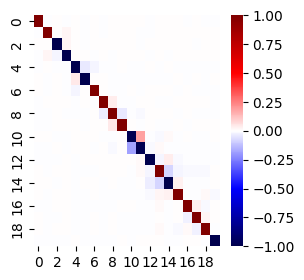

In [23]:
#cmap1 = visu(mesh1.vertlist); cmap2 = cmap1[p2p_21]
#double_plot(mesh1,mesh2,cmap1,cmap2)
fig, (ax1) = plt.subplots(1, figsize=(3, 3))
sns.heatmap(FM,ax=ax1,vmax=1.0,vmin=-1.0,cmap='seismic')

Calculate disimilarity score and plot correspondace matrix from output file *_FM.csv

disimilarity score: 20.973181470660947


<Axes: >

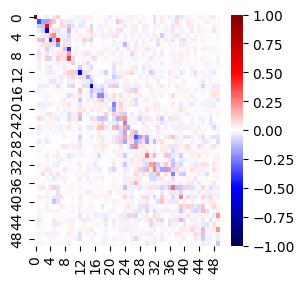

In [11]:
file_FM ='/Users/gdiazleines/results/shape-retrieval/benchmarking/RNA-monomers/shape_analysis/9gha-A_8yuo-A_FM.csv'

with open(file_FM) as csvfile:
    FM = list(csv.reader(csvfile))
    FM = np.asarray(FM, dtype=float)

#calculate disimilarity score
sim_score = calculate_geodesic_norm_score(FM)
print('disimilarity score:', sim_score)

#plot correspondance matrix
fig, (ax1) = plt.subplots(1, figsize=(3, 3))
#sns.heatmap(FM,ax=ax1,vmax=1.0,vmin=-1.0,cmap='coolwarm')
sns.heatmap(FM,ax=ax1,vmax=1.0,vmin=-1.0,cmap='seismic')

VISUALISE SURFACE DESCRIPTORS WITH ALIGNED ROTATION

In [12]:
#file_mesh1 = mesh1
#file_mesh2 = mesh2
source_path=file_mesh1
target_path=file_mesh2

map_path = '/Users/gdiazleines/results/shape-retrieval/benchmarking/RNA-monomers/shape_analysis/9gha-A_8yuo-A_p2p21.csv'
#out_gif = '/Users/gdiazleines/results/shape-retrieval/benchmarking/monomer_paper/shape_analysis/2E2Q-A_2E2N-A_correspondence.gif'
R,T=calculate_rotation_translation_fixed(source_path,target_path, map_path)
t = T.flatten()
print("det(R) =", np.linalg.det(R))
#visualize_correspondence_meshplot(source_path, target_path, map_path, R)



det(R) = 1.0000000000000009


In [13]:
mesh1_aligned, mesh2_aligned = compute_aligned_meshes(
    file_mesh1,
    file_mesh2,
    R
)

In [14]:
plot_lines(mesh1_aligned, mesh2_aligned, p2p_21, n_points=40, pretty=True,  dist_ratio=2)

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.034961…

In [ ]:
model = set_FM_model_parameters(mesh1_aligned,mesh2_aligned,neigvecs,n_ev,ndescr,step,landmarks,descr)
p2p_21,FM = calculate_functional_maps(model,n_cpus=8,refine=None)


Computing Laplacian spectrum
Computing 200 eigenvectors
	Done in 25.20 s
Computing 200 eigenvectors
	Done in 27.18 s

Computing descriptors
	Normalizing descriptors

	100 out of 100 possible descriptors kept
Computing commutativity operators


ZERNIKE DESCRIPTORS

Calculate Zernike rotational invariant moments for surface meshes 

In [6]:
#input surface meshes
file_mesh1 = file_mesh1
file_mesh2 = file_mesh2

#ouput directory to save the Zernike moments 
output_dir = '/Users/gdiazleines/results/shape-retrieval/benchmarking/RNA-monomers/shape_analysis/zernike_data'   #output path for results

#Entry IDs
entry_id_1 = "9gha-A"
entry_id_2 = "8yuo-A"

#removing extra lines in .obj file (obj2grid has trouble to read extra header lines in .obj files)
remove_until_vertex(file_mesh1)
remove_until_vertex(file_mesh2)
obj2grid_binary='/Users/gdiazleines/programs/shape-retrieval/Zernike_Kihara/ob2grid/obj2grid'
map2zernike_binary = '/Users/gdiazleines/programs/shape-retrieval/Zernike_Kihara/map2zernike-2/bin/map2zernike'
#Computation of Zernike Moments
get_inv(file_mesh1,entry_id_1,map2zernike_binary, obj2grid_binary,output_dir)
get_inv(file_mesh2,entry_id_2,map2zernike_binary, obj2grid_binary,output_dir)

predict_similarity_zernike(output_dir,output_dir)

Input file: /Users/gdiazleines/results/shape-retrieval/benchmarking/RNA-monomers/shape_analysis/zernike_data/9gha-A.obj
Grid Size: 64
Output file: /Users/gdiazleines/results/shape-retrieval/benchmarking/RNA-monomers/shape_analysis/zernike_data/9gha-A.obj.grid
Input file: /Users/gdiazleines/results/shape-retrieval/benchmarking/RNA-monomers/shape_analysis/zernike_data/8yuo-A.obj
Grid Size: 64
Output file: /Users/gdiazleines/results/shape-retrieval/benchmarking/RNA-monomers/shape_analysis/zernike_data/8yuo-A.obj.grid


Compute descriptors and pair scores from a list of entries and meshes

In [75]:

meshes_dir = '/Users/gdiazleines/results/shape-retrieval/benchmarking/global_local_diff/1lyz_1a4v/meshes/fixed/' #directory containing the meshes
output_moments_dir = '/Users/gdiazleines/results/shape-retrieval/benchmarking/global_local_diff/1lyz_1a4v/zernike_data' #output directory to save Zernike moments files
output_scores_dir = '/Users/gdiazleines/results/shape-retrieval/benchmarking/global_local_diff/1lyz_1a4v/zernike_data' #output directory to save similarity scores
file_entries='/Users/gdiazleines/results/shape-retrieval/benchmarking/global_local_diff/1lyz_1a4v/list_entries.txt'

#read list of entries
with open(file_entries, 'r') as file:
    # Read all lines, stripping the newline character
    entry_list = [line.strip() for line in file]
print(np.shape(entry_list))

#read mesh files 
for entry in entry_list:
    mesh_file=os.path.join(meshes_dir,"{}.obj".format(entry))
    print(mesh_file)
    mesh = trimesh.load(mesh_file, file_type="obj")
    
    #removing extra lines in .obj file (obj2grid has trouble to read extra header lines in .obj files)
    remove_until_vertex(mesh_file)
    #compute Zernike moments for each mesh
    get_inv(mesh_file,entry,'map2zernike', 'obj2grid',output_moments_dir)
    
#compute scores for the list of files and entries and save scores file in output_scores_dir
predict_similarity_zernike(output_scores_dir,output_scores_dir)

(2,)
/Users/gdiazleines/results/shape-retrieval/benchmarking/global_local_diff/1lyz_1a4v/meshes/fixed/1LYZ.obj
Input file: /Users/gdiazleines/results/shape-retrieval/benchmarking/global_local_diff/1lyz_1a4v/zernike_data/1LYZ.obj
Grid Size: 64
Output file: /Users/gdiazleines/results/shape-retrieval/benchmarking/global_local_diff/1lyz_1a4v/zernike_data/1LYZ.obj.grid
/Users/gdiazleines/results/shape-retrieval/benchmarking/global_local_diff/1lyz_1a4v/meshes/fixed/1A4V.obj
Input file: /Users/gdiazleines/results/shape-retrieval/benchmarking/global_local_diff/1lyz_1a4v/zernike_data/1A4V.obj
Grid Size: 64
Output file: /Users/gdiazleines/results/shape-retrieval/benchmarking/global_local_diff/1lyz_1a4v/zernike_data/1A4V.obj.grid


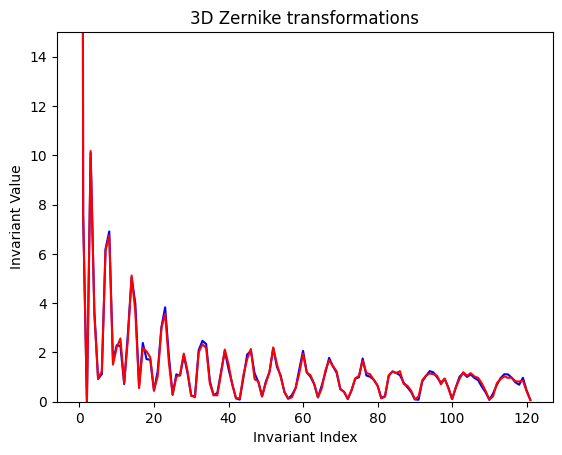

In [12]:
zernike_moments_1 = np.loadtxt("/Users/gdiazleines/results/shape-retrieval/benchmarking/RNA-monomers/shape_analysis/zernike_data/9gha-A.inv")
zernike_moments_2 = np.loadtxt("/Users/gdiazleines/results/shape-retrieval/benchmarking/RNA-monomers/shape_analysis/zernike_data/4ybb-AA.inv")
# Plot
plt.plot(zernike_moments_1, color='blue')
plt.plot(zernike_moments_2, color='red')
plt.xlabel("Invariant Index")
plt.ylabel("Invariant Value")
plt.title("3D Zernike transformations")
plt.ylim(0, 15)
plt.show()

In [90]:
def plot_lines_clean(mesh1, mesh2, p2p, n_points=10,
                     pretty=False, rotation=None, dist_ratio=1):

    import numpy as np
    import meshplot as mp

    # -----------------------------
    # Center meshes
    # -----------------------------
    def center(v):
        return v - v.mean(axis=0, keepdims=True)

    v1 = center(mesh1.vertlist)
    v2 = center(mesh2.vertlist)

    if rotation is not None:
        v1 = v1 @ rotation.T
        v2 = v2 @ rotation.T

    # -----------------------------
    # Side-by-side placement
    # -----------------------------
    gap = (v1[:, 0].max() - v1[:, 0].min()) * (1 + 1/dist_ratio)
    v2 = v2 + np.array([gap, 0, 0])

    # -----------------------------
    # SHADING (pretty option)
    # -----------------------------
    shading_m = {}
    if pretty:
        shading_m = utils.get_smooth_shading(flat=False)

    # -----------------------------
    # CORRESPONDENCE MASKS
    # -----------------------------
    m1 = np.zeros(mesh1.n_vertices)
    m2 = np.ones(mesh2.n_vertices)   # mesh2 fully active

    m1[p2p] = 1.0                    # mapped regions in mesh1

    # -----------------------------
    # COLORS (DARK BASE + YELLOW ACTIVE)
    # -----------------------------
    dark = np.array([0.4, 0.4, 0.4])   # darker than before
    
    yellow = np.array([1.0, 0.85, 0.0])

    c1 = np.where(m1[:, None] > 0, yellow, dark)
    c2 = np.where(m2[:, None] > 0, yellow, dark)

    # -----------------------------
    # Plot meshes
    # -----------------------------
    p = mp.plot(
        v1,
        mesh1.facelist,
        c=c1,
        shading=shading_m
    )

    p.add_mesh(
        v2,
        mesh2.facelist,
        c=c2,
        shading=shading_m
    )

    # -----------------------------
    # Correspondence lines
    # -----------------------------
   # fps = mesh2.extract_fps(n_points, geodesic=False)

    #for i in fps:
    #    j = p2p[i]

    #    p.add_lines(
    #        v2[i],
    #        v1[j],
    #        shading={"line_color": "gold"}
    #    )

    return p

In [127]:
plot_lines_clean(mesh1_aligned, mesh2_aligned, p2p_21, n_points=30,pretty=True,  dist_ratio=2)

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0235196…

In [44]:
plot_lines(mesh1_aligned, mesh2_aligned, p2p_21, n_points=20, pretty=True,  dist_ratio=2)

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0202657…